# Objectif 

Date de création : 18/05/2026
Illustration de la méthode de filtrage dans le plan (f, k) sur la séquence 144. 

In [1]:
# %matplotlib ipympl

import os
import sys
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# from misc import mult_along_axis
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.simu.sensi_simu_utils import (
    run_full_study,
    compute_rtf_dataset,
    plot_intensity,
    plot_tl_pi_frequency_range_plan,
    get_dist
)

# from propa.rtf.rtf_utils import D_hermitian_angle_fast
import source.global_constants as g
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    SmallFigure,
    color,
    set_subfigures_abc_labels,
)


from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

In [2]:
fig_folder = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\illustration\filtrage_k\144"

In [3]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only pulses emitted between OBS1 and OBS3
pulse_slice = (40, 180)     # Only between OBS1 and OBS3
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [6]:
print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")


Signal properties for sequence 144:
	Number of pulses: 141
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds


# Étape 2 : calcul du vecteur de RTFs
Le vecteur de RTF est estimé pour chaque position de la source à l'aide de la méthode CS-EVD et par déconvolution. 

## Définition des paramètres du processeur

In [7]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study
    "tau_rtf_analysis": 8.1,
    "alpha_overlap": 0.95,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

## Calcul des RTFs

In [8]:
###########################
# Dummy
###########################
id_library = 11

active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# rtf_mfp_processor.compute_library(
#     active_feature_args=active_replicas_args,
#     passive_feature_args=passive_replicas_args,
#     id=id_library,
# )

## Chargement des données 

In [9]:
# Select frequency range
fmin = 400
fmax = 800

In [10]:
root_libpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library"
fpath = os.path.join(root_libpath, f"library_{id_library}.nc")
ds_lib = xr.open_dataset(fpath)
ds_lib

<xarray.Dataset> Size: 51MB
Dimensions:           (h_index: 3, f_rtf: 8193, replica_id: 141, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int64 24B 1 2 3
  * f_rtf             (f_rtf) float32 33kB 0.0 0.1221 0.2441 ... 999.9 1e+03
  * replica_id        (replica_id) int64 1kB 0 1 2 3 4 5 ... 136 137 138 139 140
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 14MB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 14MB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 9MB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 9MB ...
    feature_psd       (f_rtf, replica_id) float32 5MB ...
    e_replica         (replica_id) float32 564B ...
    n_replica         (replica_id) float32 564B ...
    u_replica         (replica_id) float32 564B ...
    replica_type      (replica_id) int64 1kB ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     11

In [11]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_144_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 202MB
Dimensions:                     (h_index: 3, time: 2272470, pulse_id: 141,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 8193,
                                 f_csdm: 8193, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int64 24B 1 2 3
  * time                        (time) float32 9MB 0.0 0.0005 ... 1.136e+03
  * pulse_id                    (pulse_id) int32 564B 40 41 42 ... 178 179 180
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * f_csdm                      (f_csdm) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * h_index_bis                 (h_index_bis) int64 24B 1 2 3
Data variables:
    signal                      (h_index, time) float32 27MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 2kB ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 18MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 9MB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 9MB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 14MB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 14MB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 42MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 42MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 9MB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 9MB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        6.226
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_10-56-25
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     10.04

### Données des OBS 

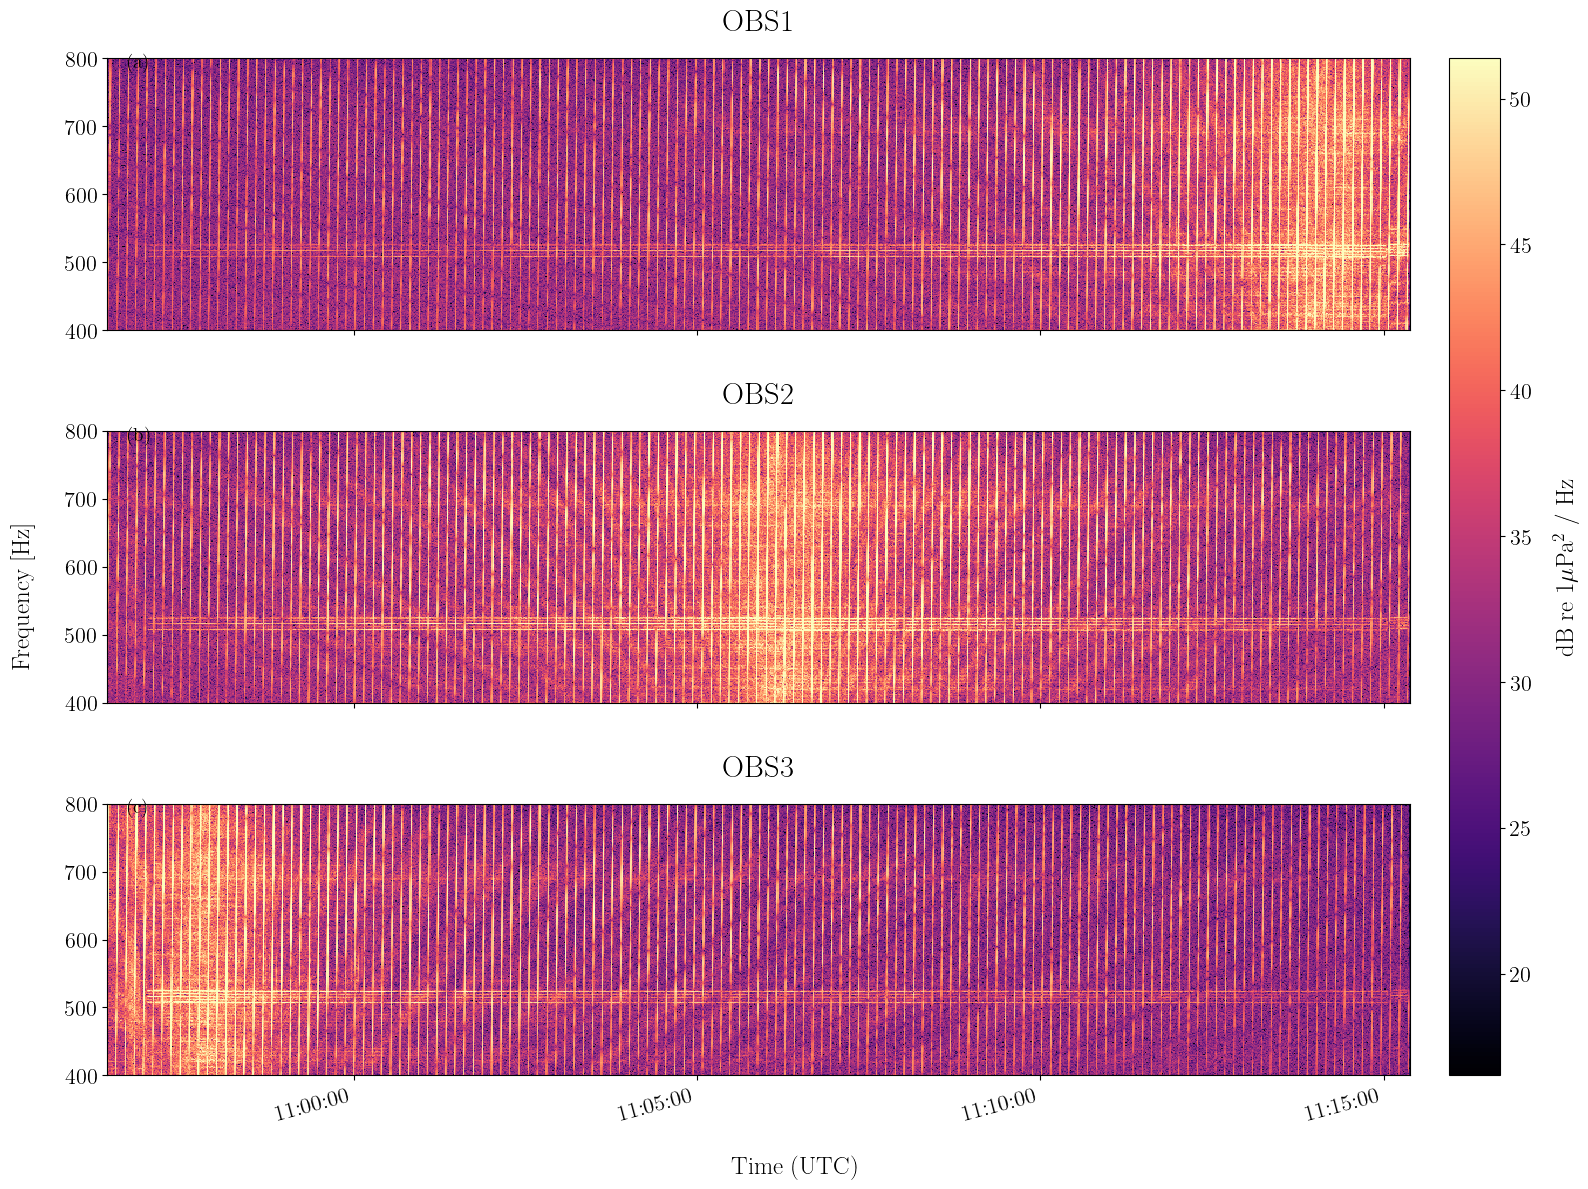

In [12]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

plot_sequence_spectrogram(
    ds_sig,
    ds_wav,
    fig_folder,
    nperseg=2**12,
    noverlap=2**11,
    fmin=fmin,
    fmax=fmax,
    fname="sequence_signal_spectrogram.png",
)

## Variations du module de $\Pi$ dans le plan (f, pos)


On s'intéresse aux variations de $\lvert \Pi \rvert$ dans le plan (f, numéro de réplique).

In [13]:
dist_rcv = get_dist_to_rcv(ds_lib)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds_lib.replica_id.values

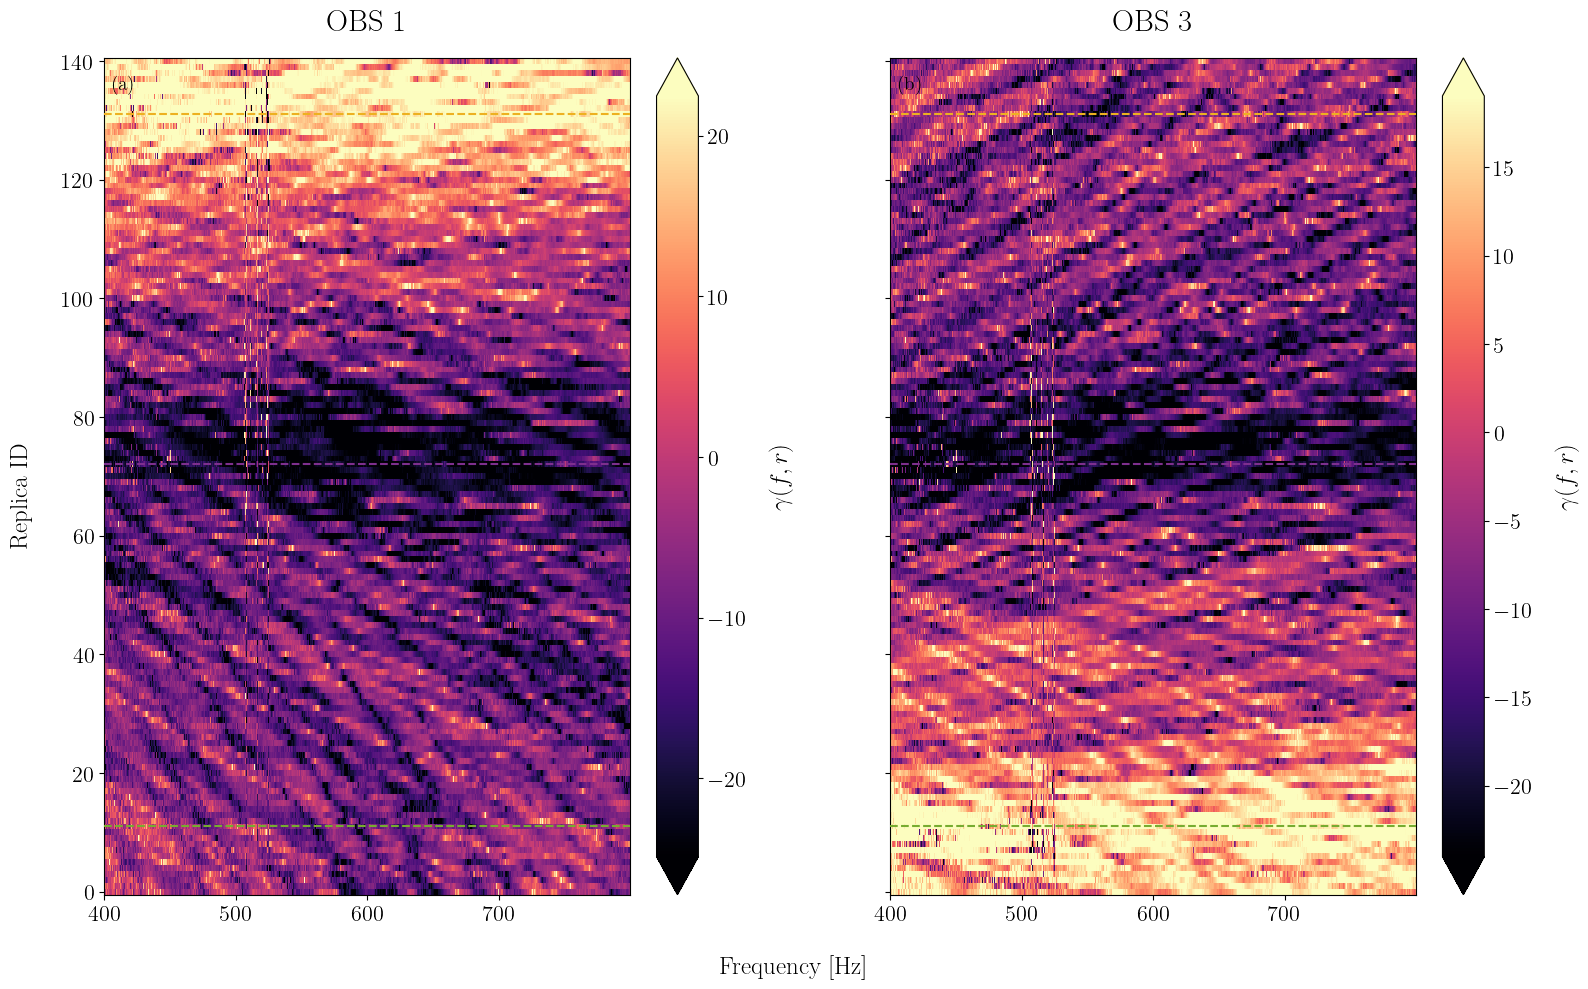

In [14]:
plot_gamma_along_sequence(
    ds_lib,
    dist_rcv,
    obs_cpa_idx,
    reps,
    fig_folder,
    replica_id_slice=slice(0, 500),
    fmin=fmin,
    fmax=fmax,
    fname="rtf_mod_along_sequence.png",
)

# Filtrage dans le plan (f, k)


L'objectif est d'extraire l'information associée aux interférences modales de grandes longueurs d'ondes (i.e à des petits $\Delta_{k{mn}}$) afin d'obtenir un lobe principal plus large permettant la mise en œuvre, en pratique de la méthode.

## Filtrage glissant 

Dans la suite : 

* La séquence entière est découpée en $Q$ fenêtres notées $\left ( I_q \right )_{q \in [0, Q-1]}$.
* Chaque fenêtre $I_q$ contient les estimations de $2P + 1$ vecteurs de RTF (correspondant ici à $2P + 1$ positions $r_p$ successives).
* Le recouvrement entre les fenêtres $I_q$ est de $2P$ positions $r_p$ de sorte que la fenêtre glisse d'une unique position lorsque q augmente de 1.  

In [147]:
def process_smooth(
    ds,
    P=12,
    # root_img,
    # compute_bootstrap=True,
):
    n_r = ds.replica_id.size

    # Define the size of the Iq windows
    n_overlap_I = 1
    n_I = 2 * P + 1
    # size_I_r = n_I * dr

    print(f"Selected window I size:  n_I = {n_I} samples")

    # Compute the number of I_q windows Q
    Q = int(np.floor((n_r + n_overlap_I - n_I) / n_overlap_I))
    print(f"Number of available segments I : Q = {Q}")

    # Apply smoothing
    f = ds.f_rtf.values
    qth = 0.9

    idx_rcvs = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

    smooth_data = np.ones_like(ds.rtf_amp)
    for idx_rcv in idx_rcvs:

        rtf_mod = ds.rtf_amp.sel(h_index=idx_rcv)
        rtf_mod_smooth = rtf_mod.copy().values

        for q in range(0, Q):
            I_q_inf = q * n_overlap_I
            I_q_sup = q * n_overlap_I + n_I
            I_q_center = q * n_overlap_I + P  # P = n_I // 2
            # print(I_q_inf, I_q_sup)

            # Select I_q
            rtf_I_q = rtf_mod.isel(replica_id=slice(I_q_inf, I_q_sup))
            # Apply filter
            gamma_q = 10 * np.log10(rtf_I_q**2)     # nf, nrep
            # Apply FFT along the r dimension
            gamma_q_fft = np.fft.rfft(gamma_q, axis=1)  # nf, nk
            gamma_q_psd = np.abs(gamma_q_fft)**2

            k = np.fft.rfftfreq(gamma_q.shape[1], d=1)  #   nk

            # Extract quantiles of the distribution and their corresponding x values
            gamma_q_psd_cumsum = np.cumsum(gamma_q_psd, axis=1)  # nf, nk
            gamma_q_psd_proportion = gamma_q_psd_cumsum / np.max(
            gamma_q_psd_cumsum, axis=1)[:, np.newaxis]  # nf, nk
            # q_th = np.percentile(gamma_q_psd, qth, axis=1)  # nf
            idx_xqth = np.argmin(np.abs(gamma_q_psd_proportion - qth), axis=1)  # nf
            # idx_xqth =
            x_qth = k[idx_xqth]

            # q_th = np.percentile(gamma_q_psd, qth, axis=1)  # nf
            # # # # Get abcisse corresponding to the quantiles : x_q1, mu(x_q1) = q1, x_q2, mu(x_q2) = q2, x_q3, mu(x_q3) = q3
            # dx_qth = np.abs(gamma_q_psd - q_th[:, np.newaxis])  # nf, nrep
            # idx_xqth = np.argmin(dx_qth, axis=1)
            # x_qth = k[idx_xqth]
            # print(x_qth)

            # # Smooth with rolling average to avoid abrupt changes betweens adjacent bins
            n_roll_avg = 10
            x_qth = np.convolve(x_qth, np.ones(n_roll_avg) / n_roll_avg, mode="same")

            # TODO change this
            # x_qth[:] = 0.035
            # x_qth[:] = k[0] * 0.9

            # Filter desired k
            gamma_q_fft_filt = np.copy(gamma_q_fft)  # nf, nk
            # Define dedicated mask
            kk, ff = np.meshgrid(k, f)
            mask_fk = kk > x_qth[:, np.newaxis]
            # Apply mask
            gamma_q_fft_filt[mask_fk] = 0
            gamma_q_filt = np.fft.irfft(gamma_q_fft_filt, n=rtf_I_q.shape[1], axis=1)
            rtf_mod_q_filt = 10 ** (gamma_q_filt / 20)

            if q == 0:
                plt.figure()
                plt.plot(k, gamma_q_psd_proportion[0, :], color="k")
                # plt.plot(k, gamma_q_psd_proportion[10, :])
                plt.axvline(x_qth[0], color=color(1), label=f"th = {int(qth*100)} \%")
                plt.xlabel("k [1/m]")
                plt.ylabel("Cumulative proportion of " + r"$\lvert \Gamma(f, k) \rvert^2$")
                plt.legend(fontsize=18)
                plt.title(f"OBS{idx_rcv} - Segment {q}")


                plt.figure()
                gamma_q.plot(x="replica_id", cmap="magma", cbar_kwargs={"label": r"$ \gamma(f, i) $"})
                plt.xlabel("Replica ID")
                plt.title(f"OBS{idx_rcv} - Segment {q}")


                plt.figure()
                vmin = np.percentile(gamma_q_psd, 10)
                vmax = np.percentile(gamma_q_psd, 90)
                im = plt.pcolormesh(f, k, gamma_q_psd.T, cmap="magma", vmax=vmax, vmin=vmin)
                plt.plot(f, x_qth, color="cyan", label=r"$k_0$", zorder=10)
                plt.colorbar(im, label=r"$\lvert \Gamma(f, k) \rvert^2$")
                plt.xlabel("f [Hz]")
                plt.ylabel("k [1/m]")
                plt.legend(fontsize=18)
                plt.title(f"OBS{idx_rcv} - Segment {q}")


                plt.figure()
                gamma_q_filt_psd = np.abs(gamma_q_fft_filt) ** 2
                vmin = np.percentile(gamma_q_filt_psd, 10)
                vmax = np.percentile(gamma_q_filt_psd, 90)
                im = plt.pcolormesh(
                    f,
                    k,
                    np.abs(gamma_q_filt_psd).T,
                    cmap="magma",
                    vmax=vmax,
                    vmin=vmin,
                )
                plt.plot(f, x_qth, color="cyan", label=r"$k_0$", zorder=10)
                plt.colorbar(im, label=r"$\lvert \tilde{\Gamma}(f, k) \rvert^2$")
                plt.xlabel("f [Hz]")
                plt.ylabel("k [1/m]")
                plt.legend(fontsize=18)
                plt.title(f"OBS{idx_rcv} - Segment {q}")


                plt.figure()
                rtf_I_q_filt_xr = xr.zeros_like(rtf_I_q)
                rtf_I_q_filt_xr.data = gamma_q_filt
                rtf_I_q_filt_plot = 10 * np.log10(rtf_I_q_filt_xr**2)
                rtf_I_q_filt_plot.plot(x="replica_id", cmap="magma", cbar_kwargs={"label": r"$ \tilde{\gamma}(f, i) $"})
                plt.xlabel("Replica ID")
                plt.title(f"OBS{idx_rcv} - Segment {q}")
                # print(I_q_center)

            # Store modified rtf
            rtf_mod_smooth[:, I_q_center] = rtf_mod_q_filt[:, P]
            # rtf_I_q_filt_P = rtf_I_q_filt[:, P]     # Center of the box
            # smooth_rtfs.append(rtf_I_q_filt_P)

        i_rcv = np.argmin(np.abs(ds_lib.h_index.values - idx_rcv))
        smooth_data[i_rcv, ...] = rtf_mod_smooth

    ds_smooth = ds.copy()
    ds_smooth.rtf_amp.data = smooth_data

    dist_rcv = get_dist_to_rcv(ds=ds)

    # Plot comparison
    # plot_gamma_along_sequence(
    #     ds,
    #     dist_rcv,
    #     obs_cpa_idx,
    #     reps,
    #     fig_folder,
    #     replica_id_slice=slice(0, 500),
    #     fmin=fmin,
    #     fmax=fmax,
    # )

    plot_gamma_along_sequence(
        ds_smooth,
        dist_rcv,
        obs_cpa_idx,
        reps,
        fig_folder,
        # replica_id_slice=slice(0, 500),
        fmin=fmin,
        fmax=fmax,
        fname=f"{ds_smooth.type}_smooth_k_P{P}_gamma_along_sequence.png",
    )

    before_smooth = 20 * np.log10(ds.rtf_amp.sel(h_index=idx_rcv))
    after_smooth = 20 * np.log10(ds_smooth.rtf_amp.sel(h_index=idx_rcv))

    mid_rep = ds.replica_id.size // 2
    sel_reps = [mid_rep - 2*P, mid_rep, mid_rep + 2*P]
    for i_rep, rep in enumerate(sel_reps):
        before_smooth_rs = before_smooth.sel(replica_id=rep, method="nearest")
        after_smooth_rs = after_smooth.sel(replica_id=rep, method="nearest")

        plt.figure()
        before_smooth_rs.plot(
            x="f_rtf",
            label=f"Original (rep = {before_smooth_rs.replica_id.values:.2f})",
        )
        after_smooth_rs.plot(
            x="f_rtf", label=f"Smooth (rep = {after_smooth_rs.replica_id.values:.2f})"
        )
        plt.legend()
        # plt.xlim([550, 650])

    return ds_smooth

Selected window I size:  n_I = 21 samples
Number of available segments I : Q = 121


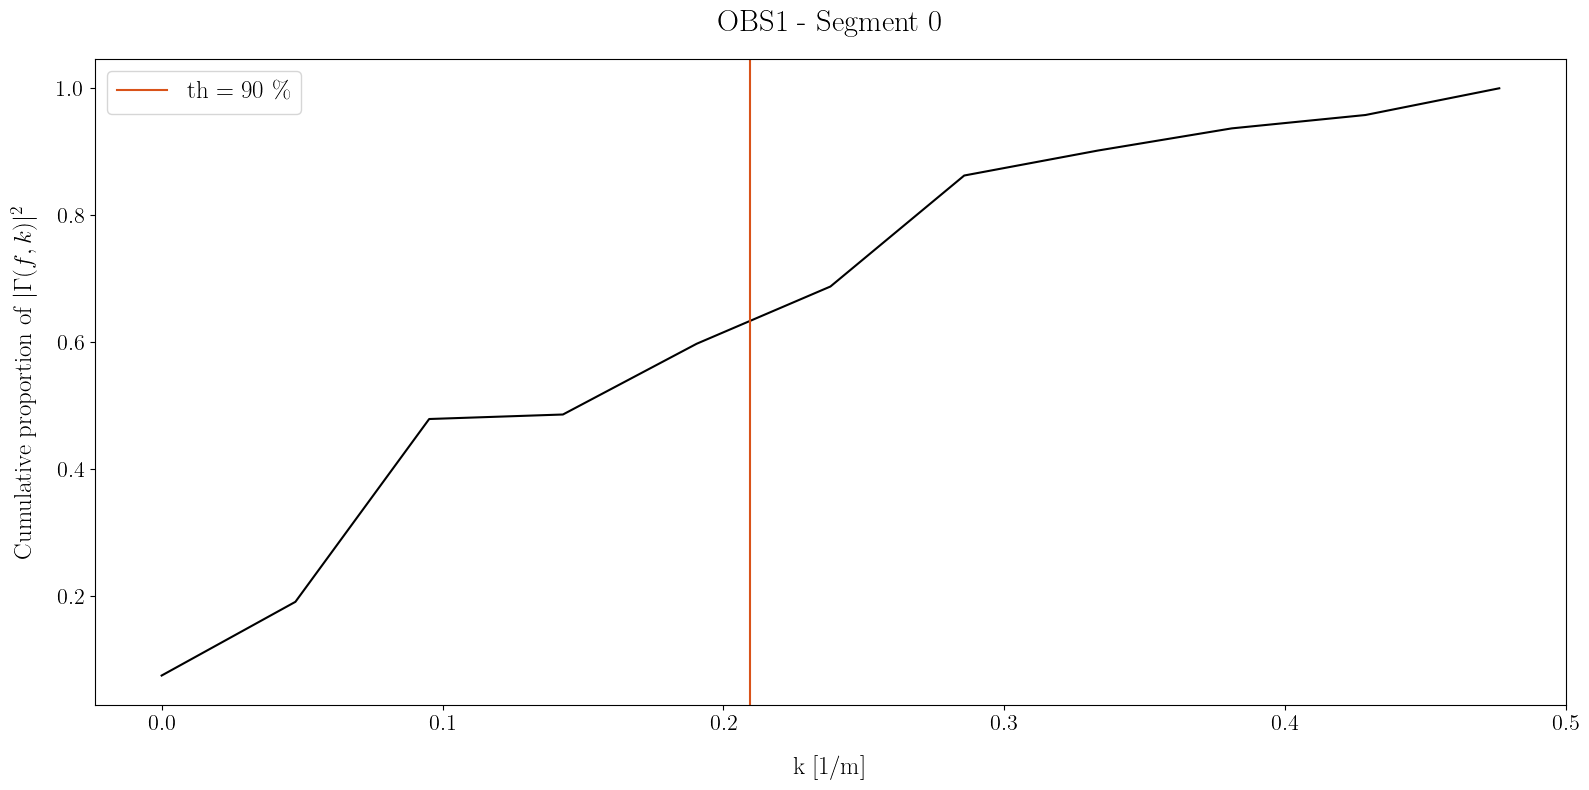

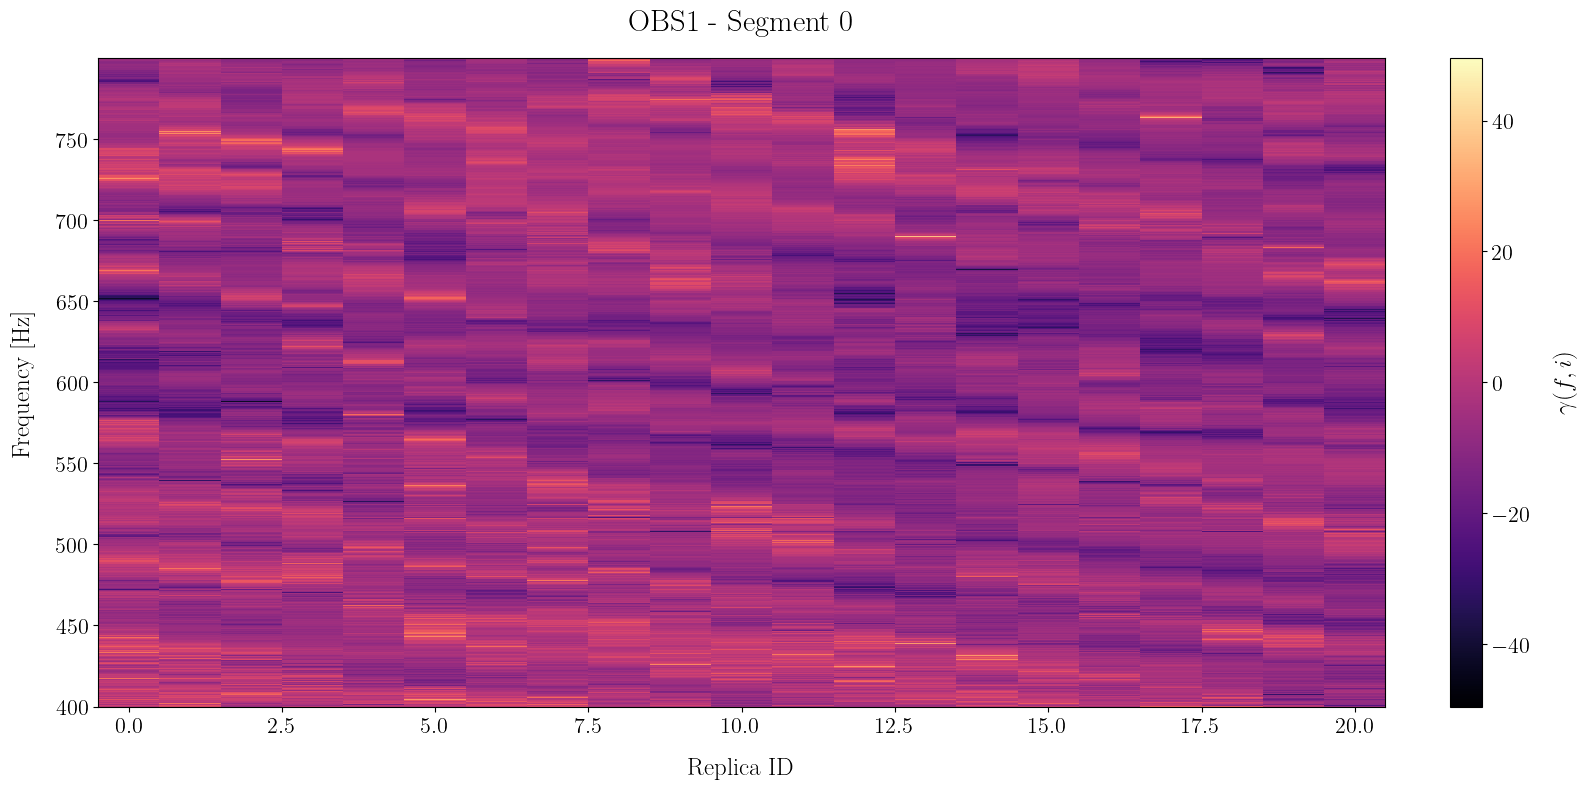

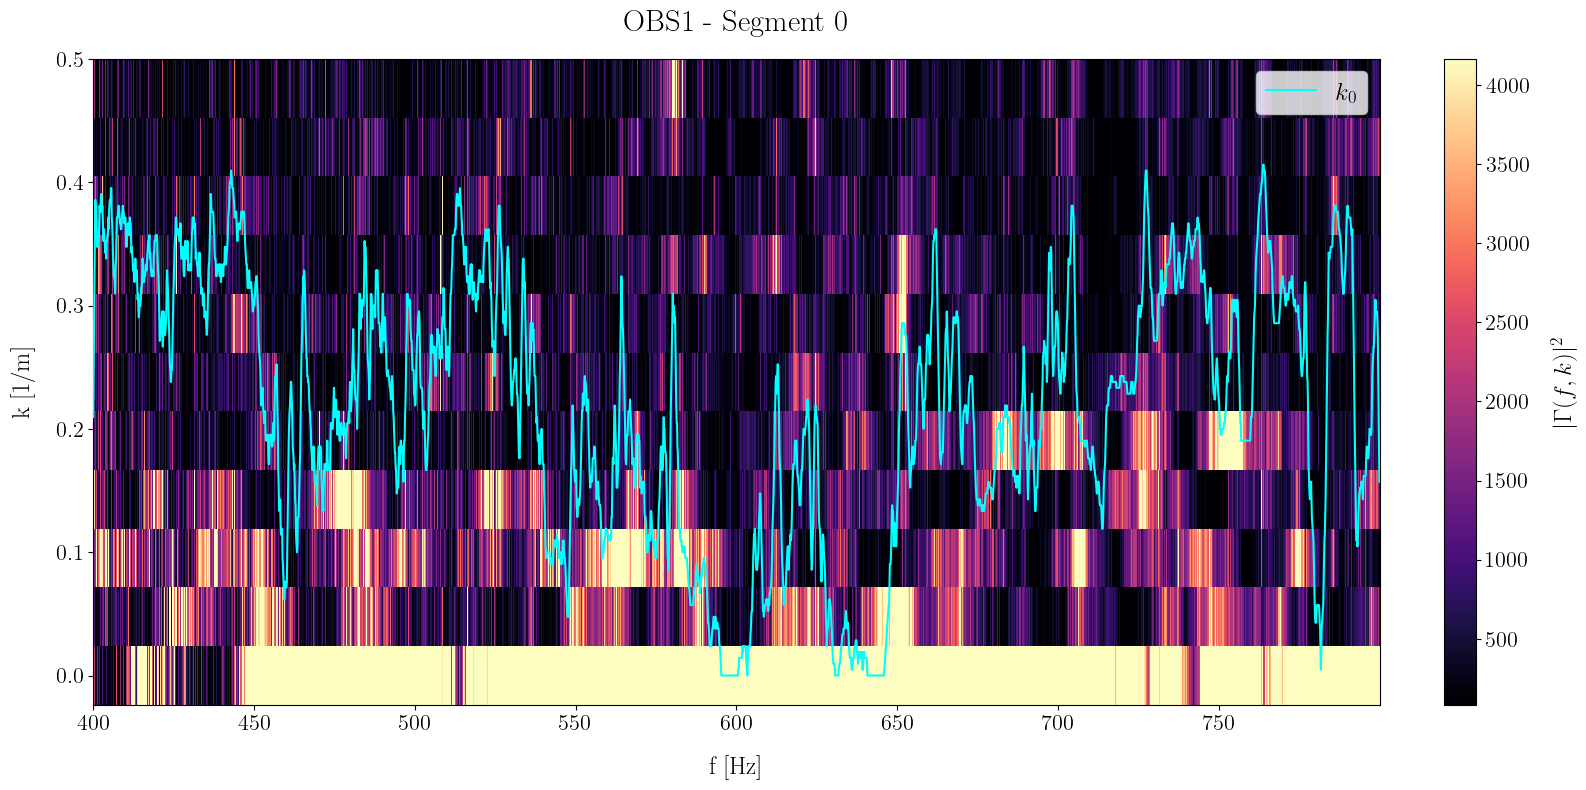

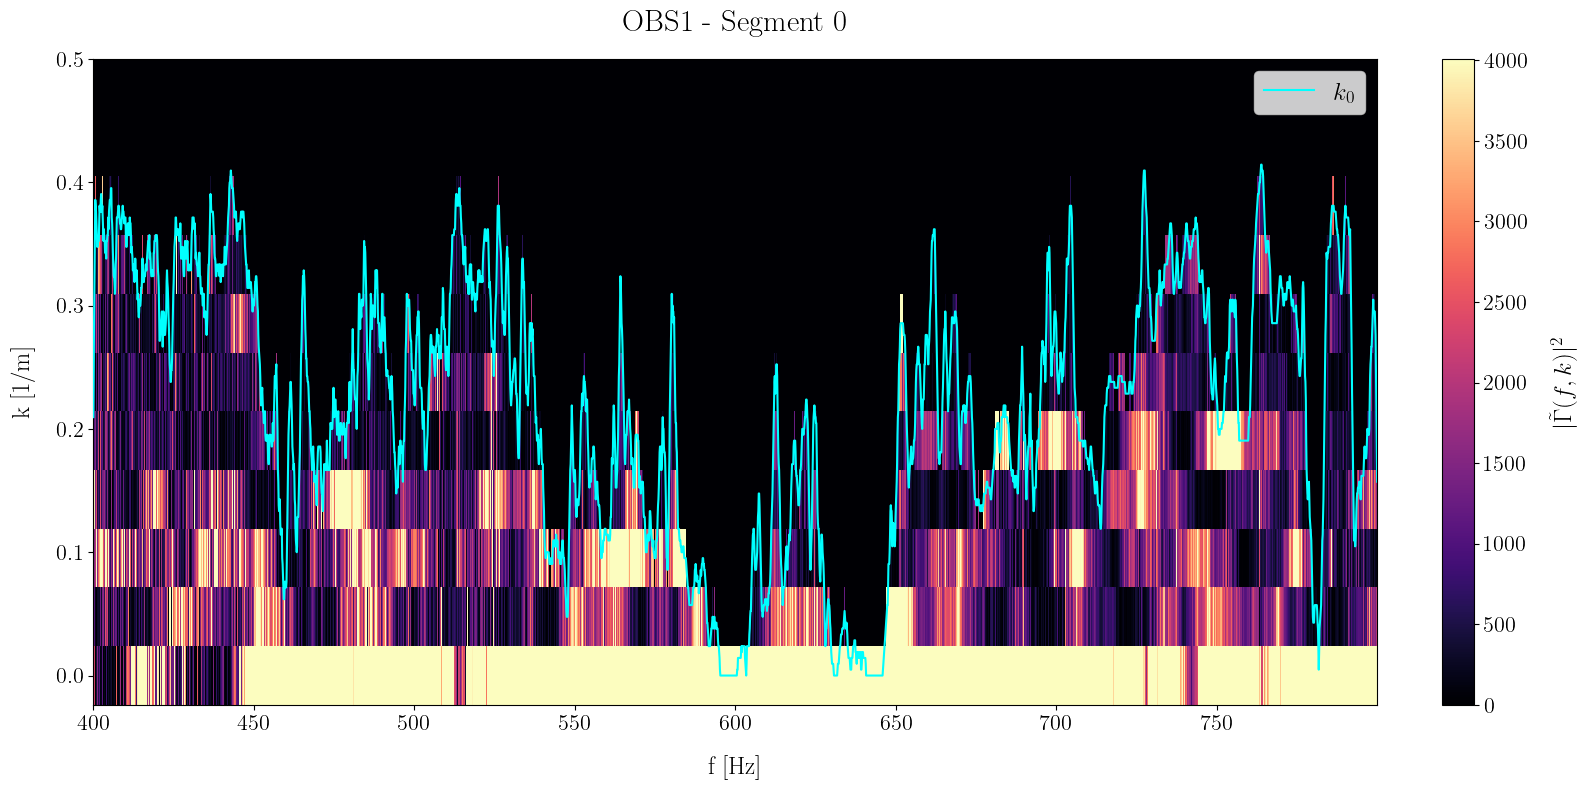

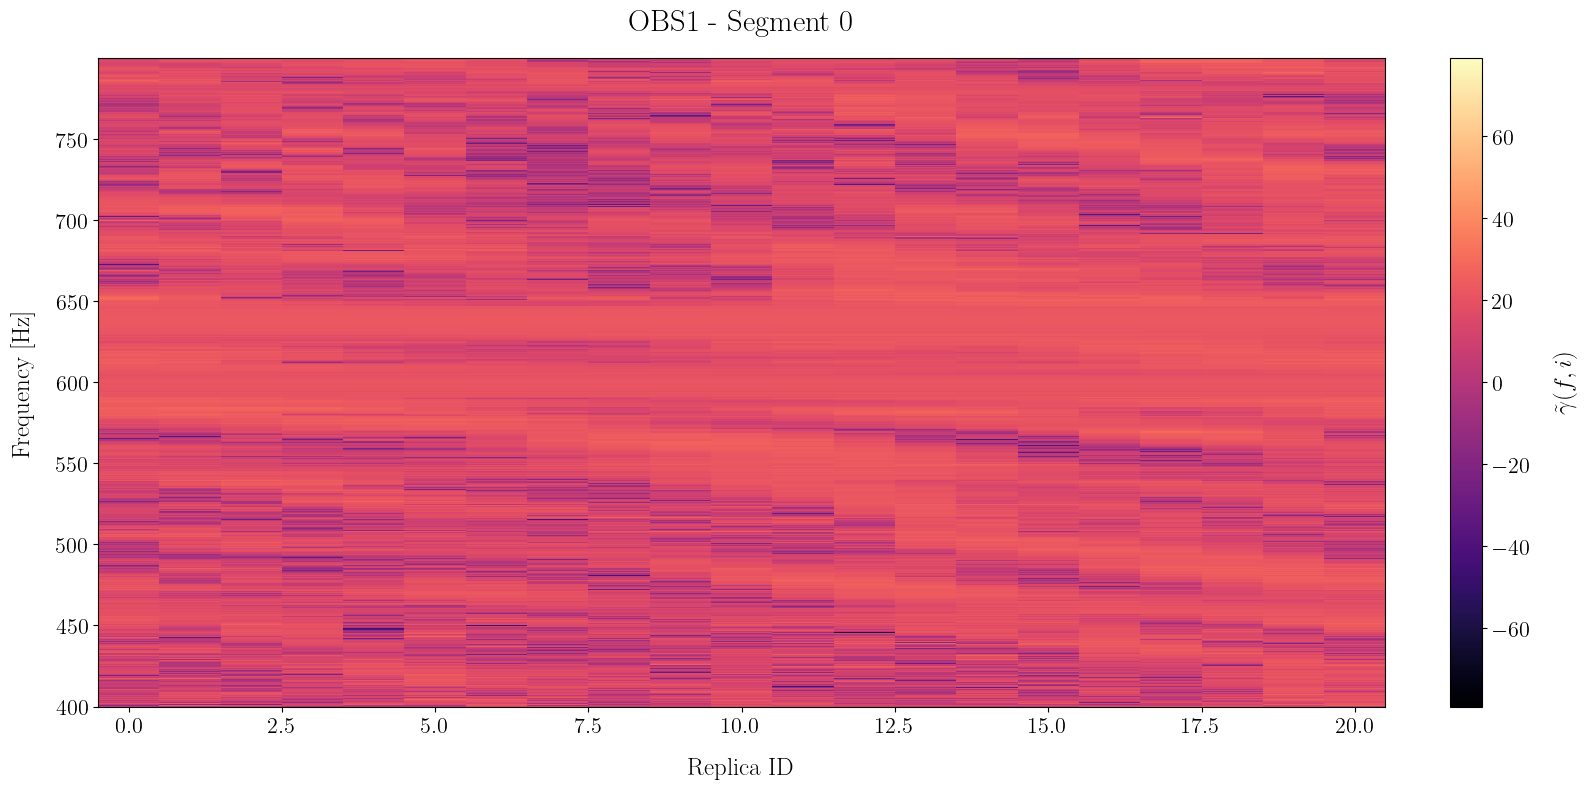

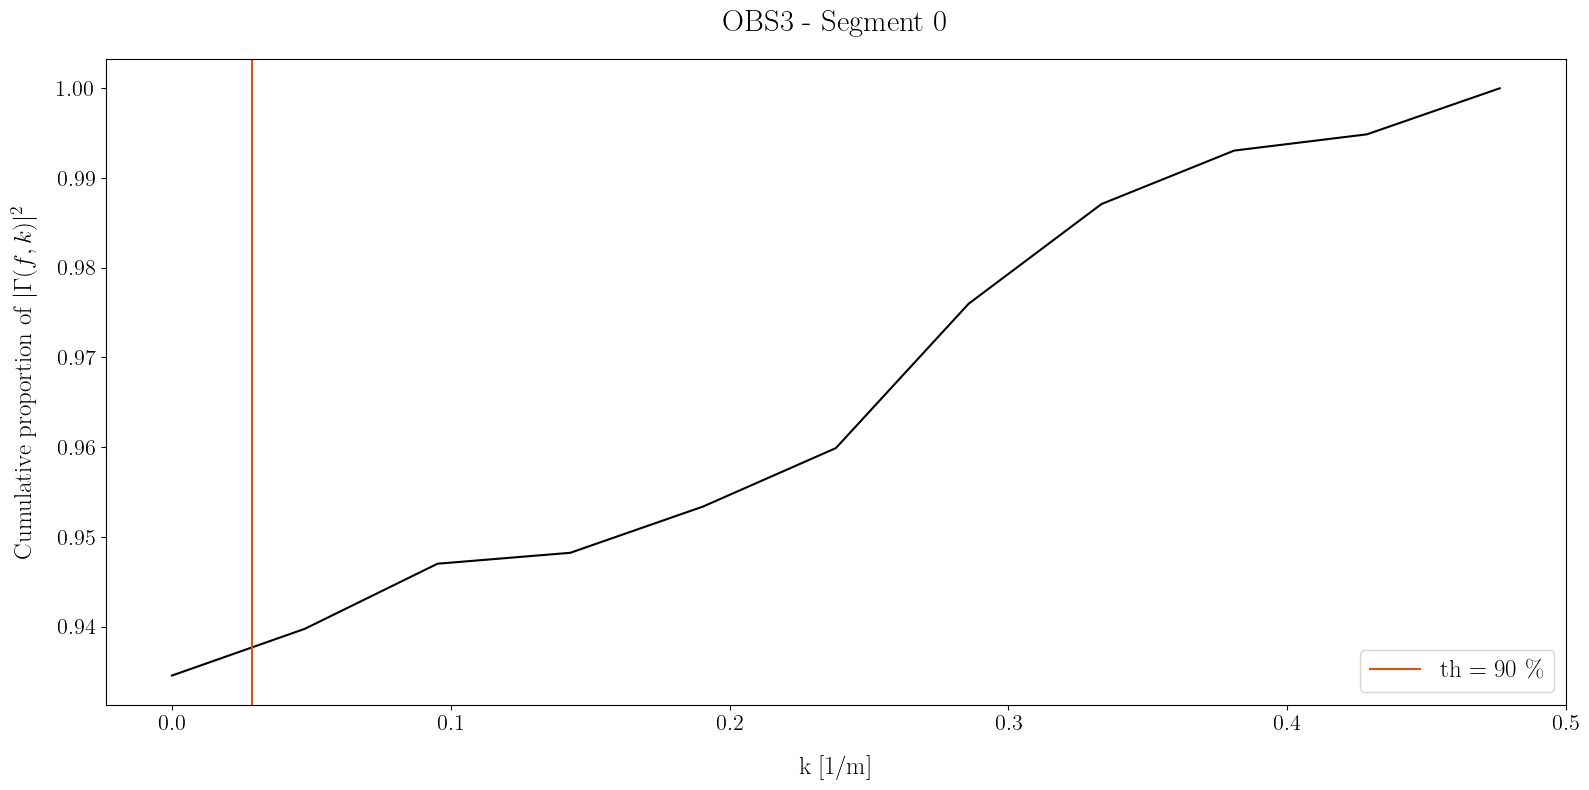

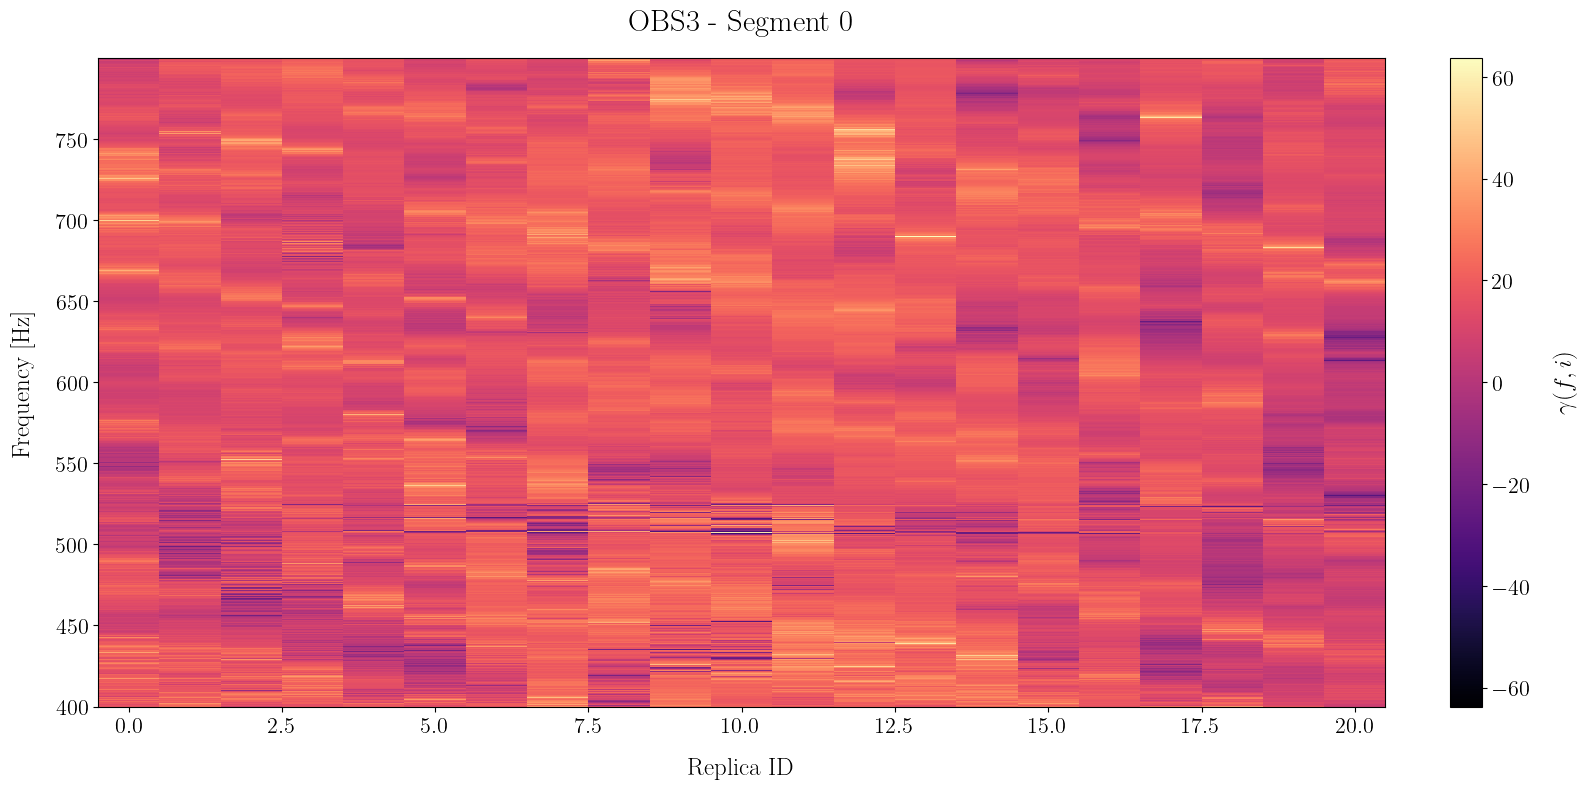

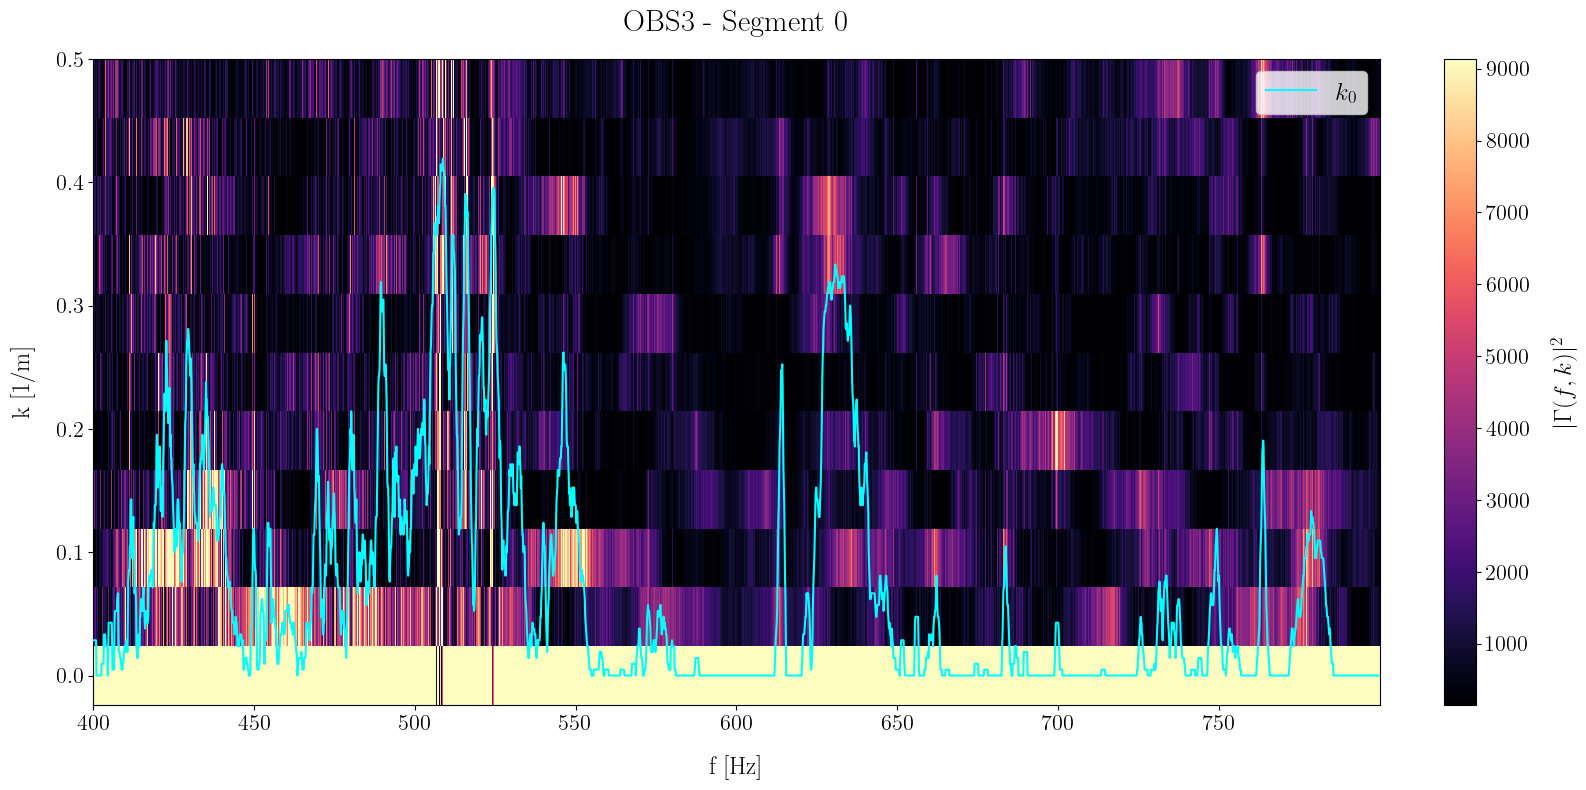

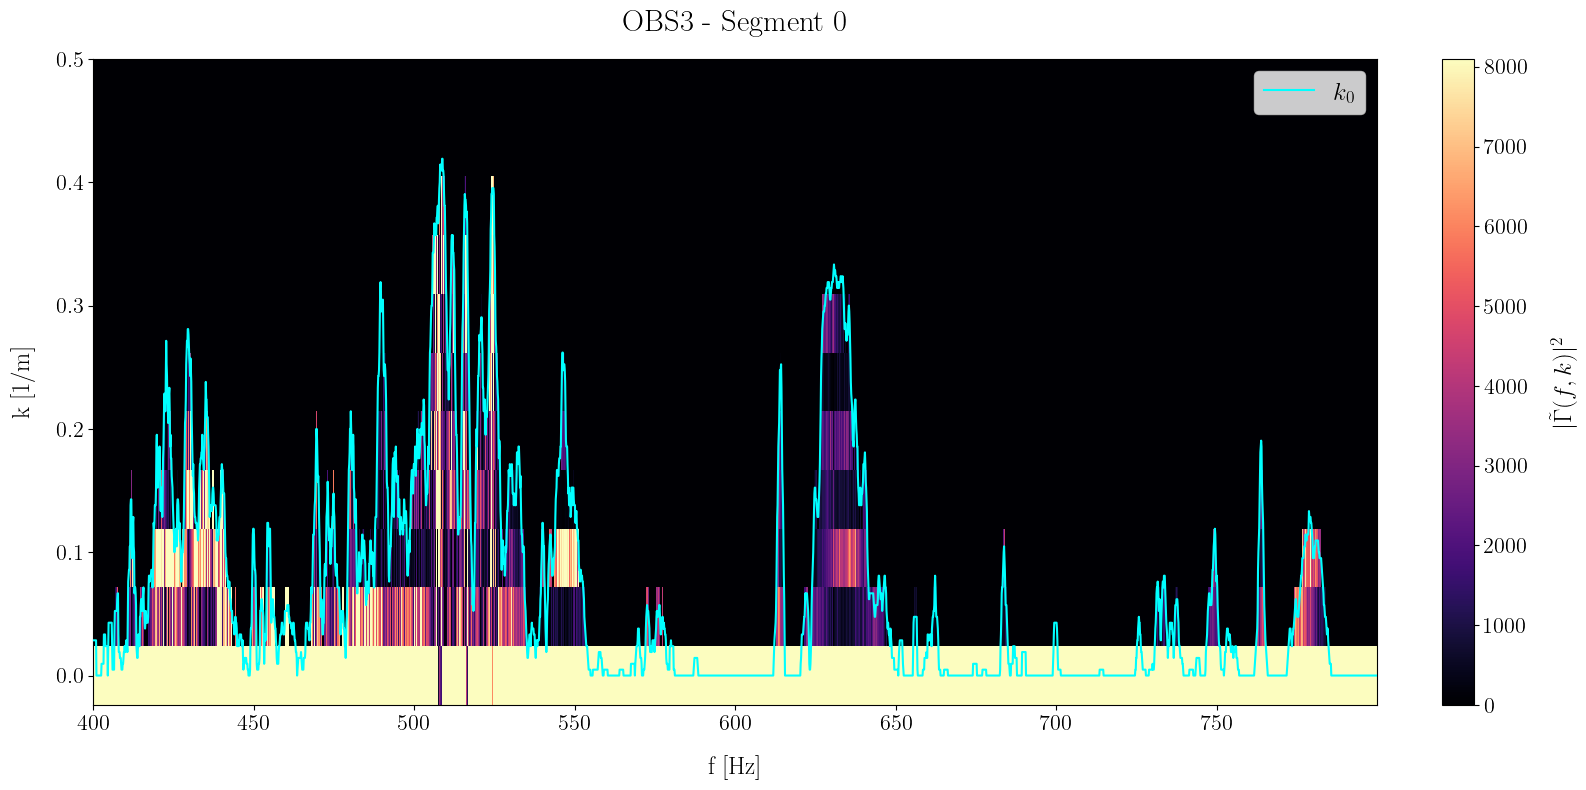

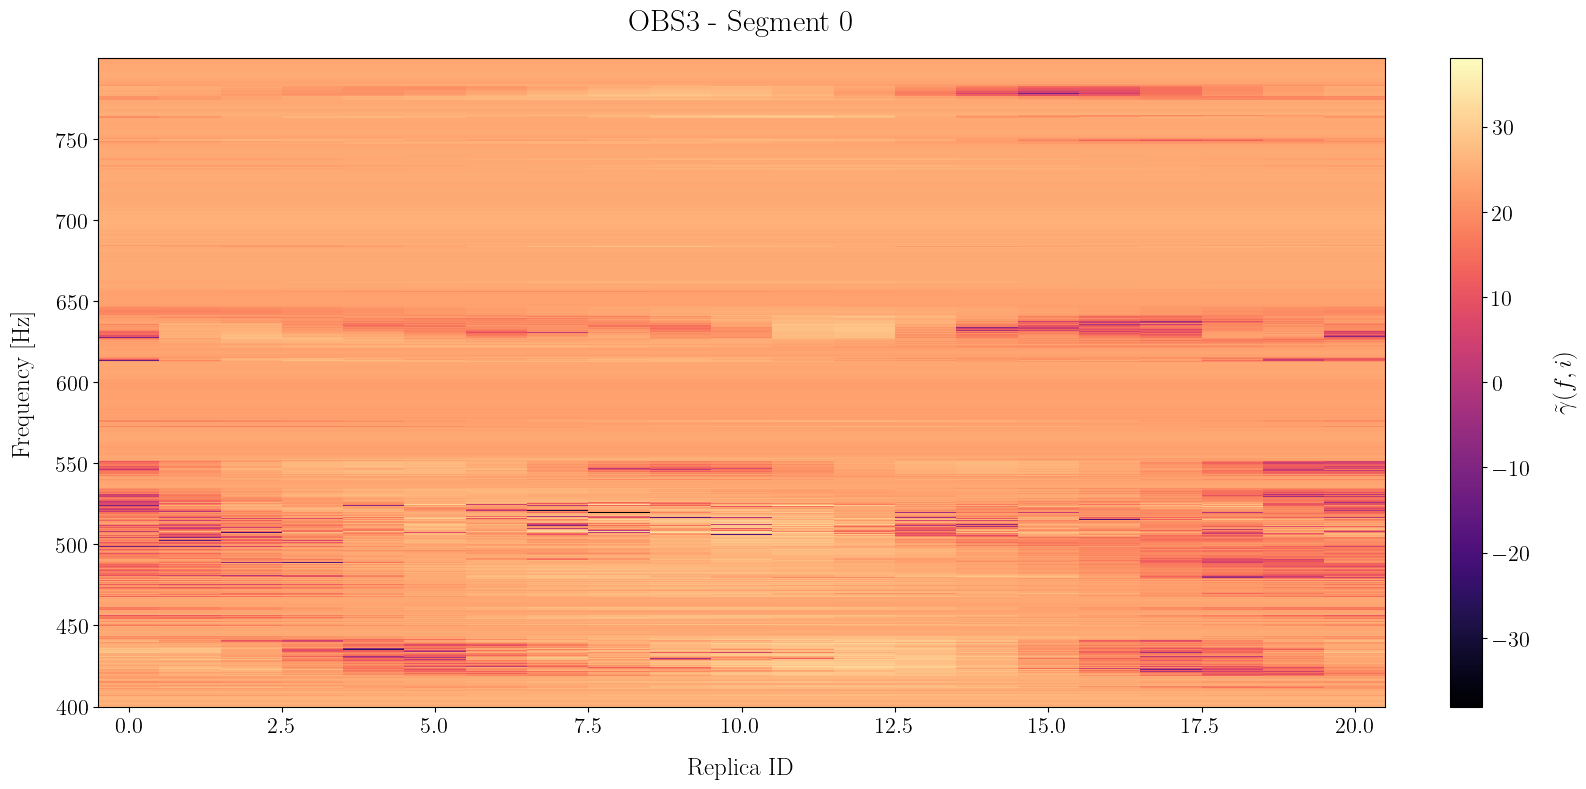

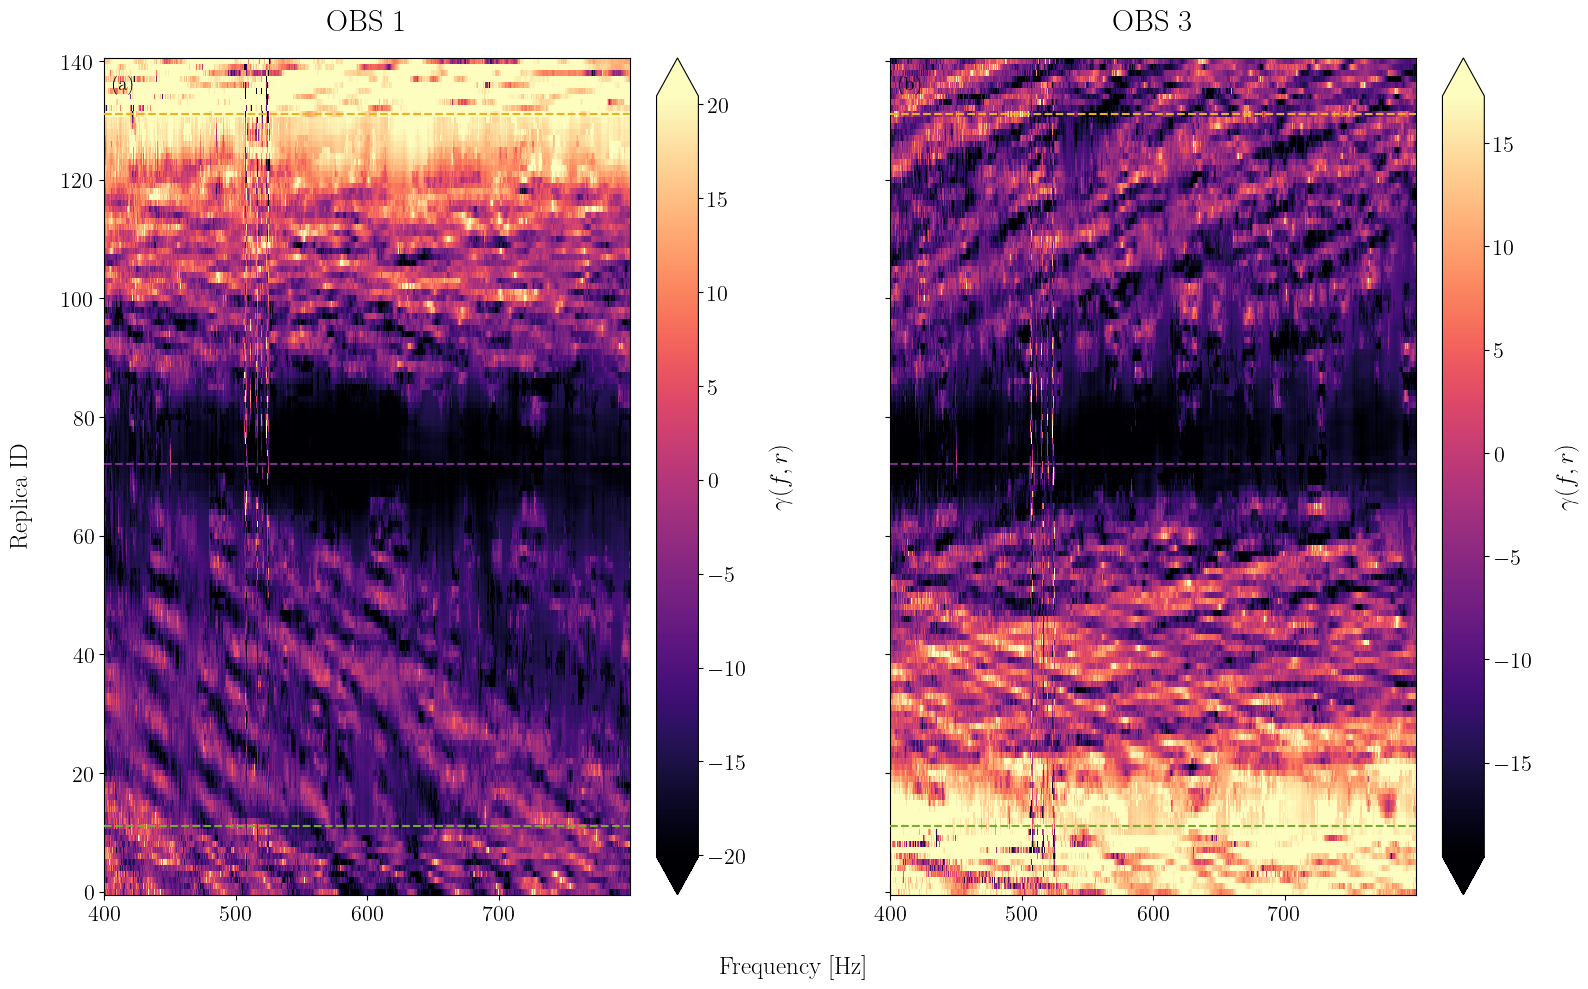

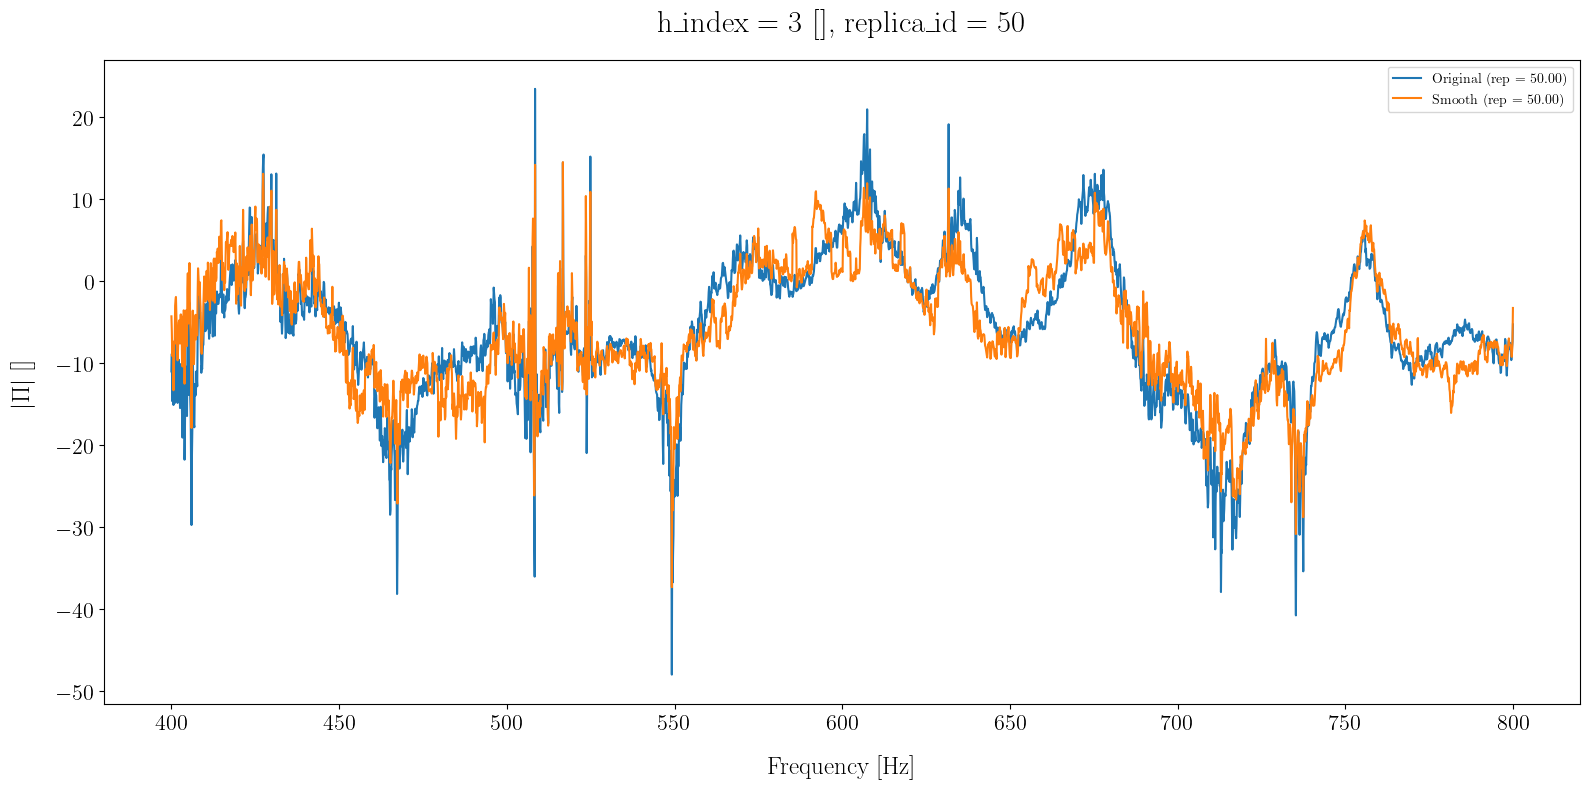

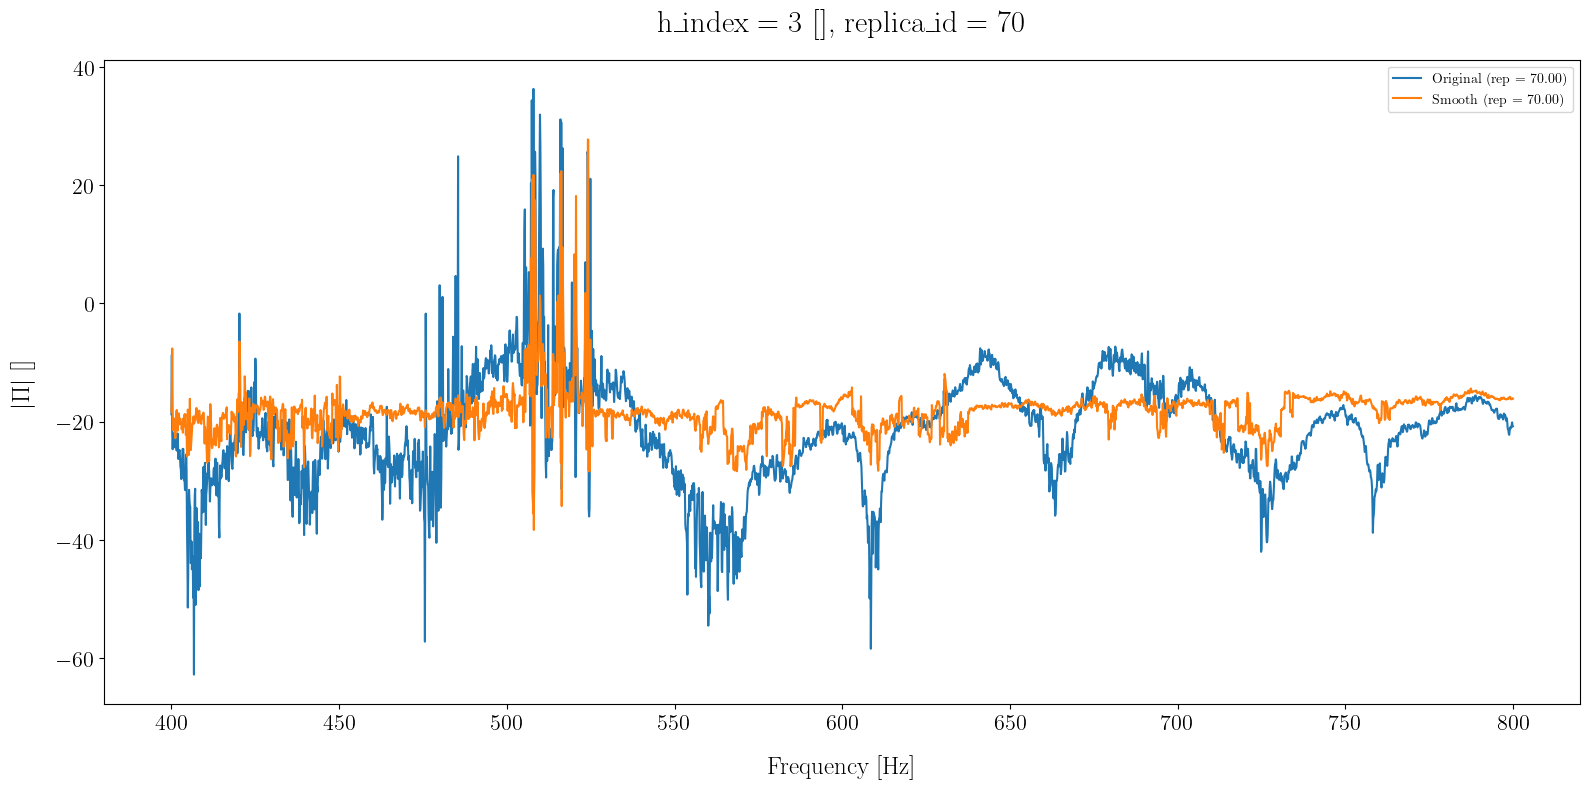

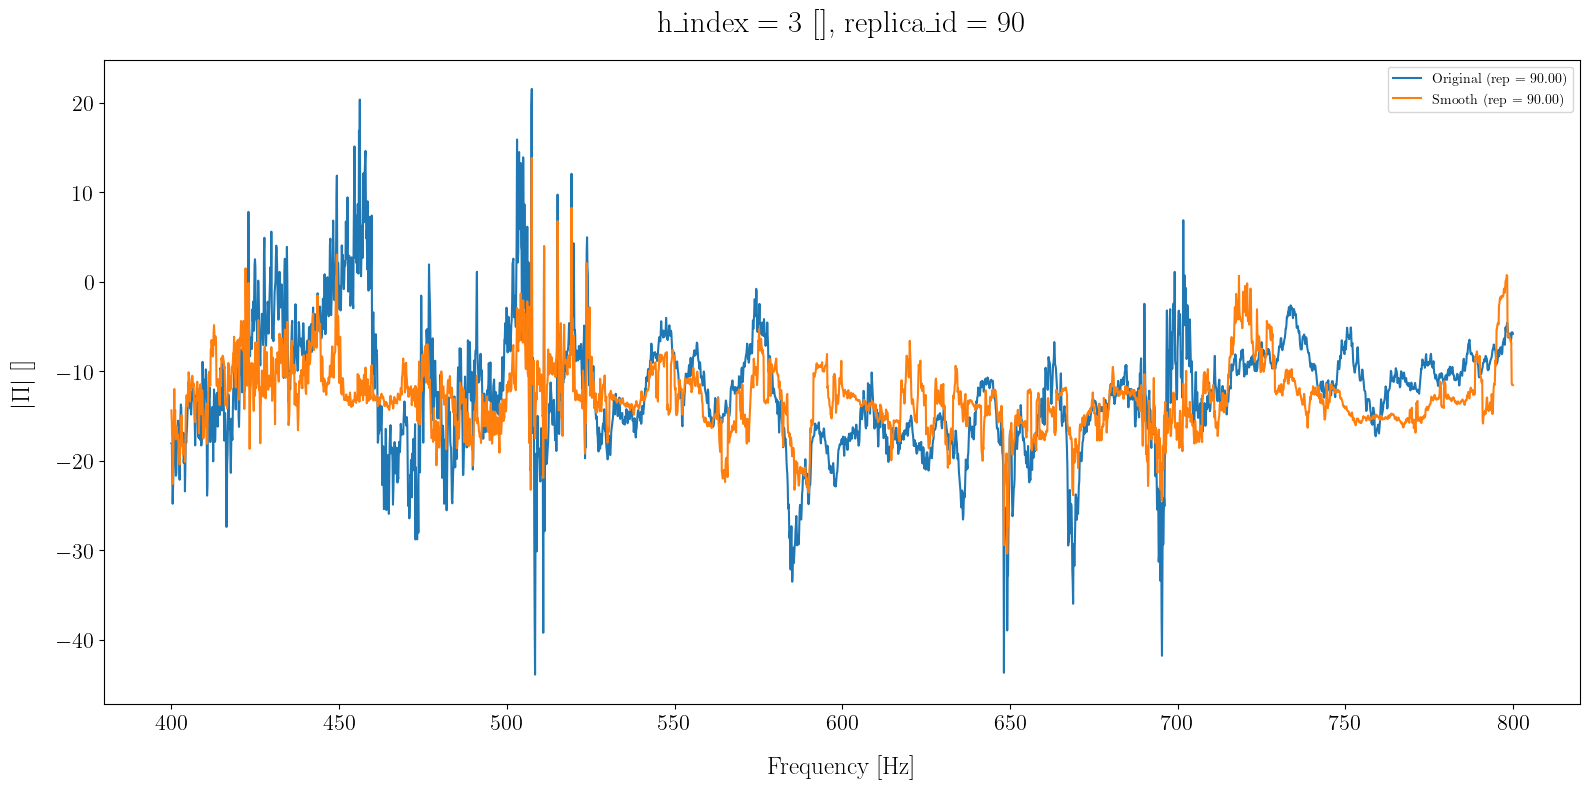

In [148]:
ds_lib = ds_lib.sel(f_rtf=slice(fmin, fmax))
ds_lib_smooth = process_smooth(
    ds=ds_lib,
    P=10,
)

In [117]:
from misc import cast_matrix_to_target_shape
def get_bootstrap_dist(ds_, test_replica_id, estimator="deconv", dist_type="hermitian_angle"):
    # Select one replica_id to compare using bootstrap
    test_replica = ds_.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds_

    if estimator == "deconv":
        # Test RTF
        test_replica_rtf = test_replica.rtf_amp_deconv * np.exp(
            1j * test_replica.rtf_phase_deconv
        )

        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp_deconv * np.exp(
            1j * bootstrap_replica.rtf_phase_deconv
        )
    elif estimator == "cs-evd":
        # Test RTF
        test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
            1j * bootstrap_replica.rtf_phase
        )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # # Compute dist
    if dist_type == "hermitian_angle":
        dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False, "apply_median": True}
        dist = D_hermitian_angle_fast(
            rtf_ref=test_replica_rtf.values,
            rtf=bootstrap_replica_rtfs,
            **dist_kwargs,
        )

    # Distance module
    elif dist_type == "hermitian_angle_module":
        rtf_ref = np.abs(test_replica_rtf.values)
        rtf = np.abs(bootstrap_replica_rtfs)

        dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False, "apply_median": True, "data_space": "real"}
        dist = D_hermitian_angle_fast(
            rtf_ref=rtf_ref,
            rtf=rtf,
            **dist_kwargs,
        )

    elif dist_type == "norm_L1":
        rtf_ref = test_replica_rtf.values
        rtf = bootstrap_replica_rtfs
        rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

        d_L1 = np.sum(np.abs(rtf_ref_expanded - rtf), axis=0)
        dist = np.median(d_L1, axis=0).squeeze()  # Median along f axis

    elif dist_type == "norm_L1_module":
        rtf_ref = np.abs(test_replica_rtf.values)
        rtf = np.abs(bootstrap_replica_rtfs)
        rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

        d_L1_mod = np.sum(np.abs(rtf_ref_expanded - rtf), axis=0)
        dist = np.median(d_L1_mod, axis=0).squeeze()  # Median along f axis

    return dist 

In [118]:
def get_bootstrap_dist_matrix(ds_, estimator="cs-evd", dist_type="hermitian_angle"):
    dist_mat = []
    for i, id in enumerate(ds_.replica_id.values): 
        dist_id = get_bootstrap_dist(
            ds_=ds_, test_replica_id=id, estimator=estimator, dist_type=dist_type
        )
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [119]:
def build_dist_matrix(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    spatial_dist = cdist(rep_pos, rep_pos, metric="euclidean")

    return spatial_dist

In [120]:
cpa_idx = obs_cpa_idx

In [121]:
spatial_dist_mat = build_dist_matrix(ds_lib)

In [122]:
theta_mat_mod = get_bootstrap_dist_matrix(
    ds_=ds_lib, estimator="cs-evd", dist_type="hermitian_angle_module"
)

In [149]:
theta_mat_mod_smooth = get_bootstrap_dist_matrix(
    ds_=ds_lib_smooth, estimator="cs-evd", dist_type="hermitian_angle_module"
)

#### Angle hermitien module 

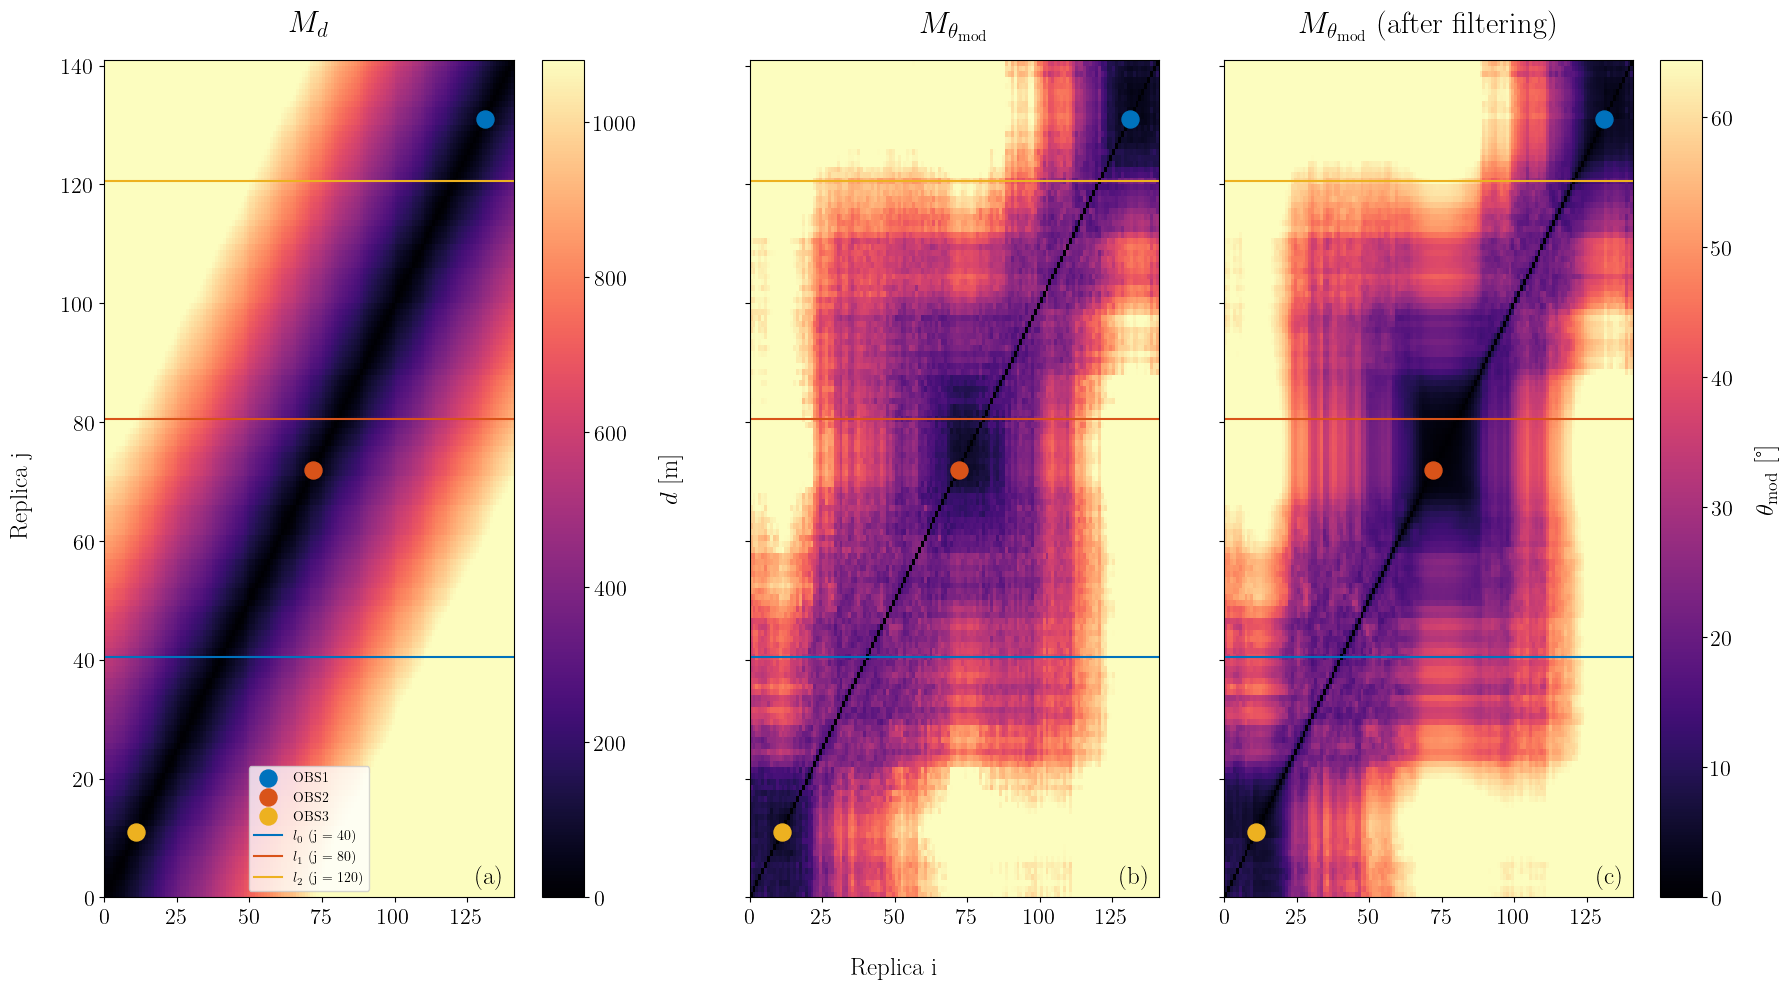

In [150]:
# Quelques lignes à la loupe
i_ls = [40, 80, 120]
fig, axs = plt.subplots(
    nrows=1, ncols=3, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2, ax3 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(spatial_dist_mat, cmap="magma", vmax=vmax)
# fig.colorbar(im, ax=ax1, orientation="vertical", label=r"$d$ [m]")
ax1.set_title(r"$M_{d}$")

clabel = r"$d$ [m]"
fig.colorbar(
    im,
    ax=[ax1],
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.07,
)

vmax = min(np.nanpercentile(theta_mat_mod, 75), np.nanpercentile(theta_mat_mod_smooth, 75))

im = ax2.pcolormesh(theta_mat_mod, cmap="magma", vmax=vmax)
ax2.set_title(r"$M_{\theta_{\text{mod}}}$")

im = ax3.pcolormesh(theta_mat_mod_smooth, cmap="magma", vmax=vmax)
ax3.set_title(r"$M_{\theta_{\text{mod}}}$ (after filtering)")


clabel = r"$\theta_{\text{mod}}$ [°]"
fig.colorbar(
    im,
    ax=[ax2, ax3],
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.03,
)

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication and lines
for ax in axs:
    for i, i_rcv in enumerate(ds_lib.h_index.values):
        ax.scatter(
            cpa_idx[i],
            cpa_idx[i],
            marker="o",
            s=150,
            color=color(i),
            label=f"OBS{i_rcv}",
        )

    for k, i_l in enumerate(i_ls):
        ax.axhline(i_l + 0.5, color=color(k), label=rf"$l_{k}$ (j = {i_l})")

ax1.legend()
# ax2.legend()

set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.98, y_pos=0.01, ha="right", va="bottom"
)

fpath = os.path.join(
    fig_folder,
    f"bootstrap_theta_mod_cs_evd_deconv.png",
)

plt.savefig(fpath)

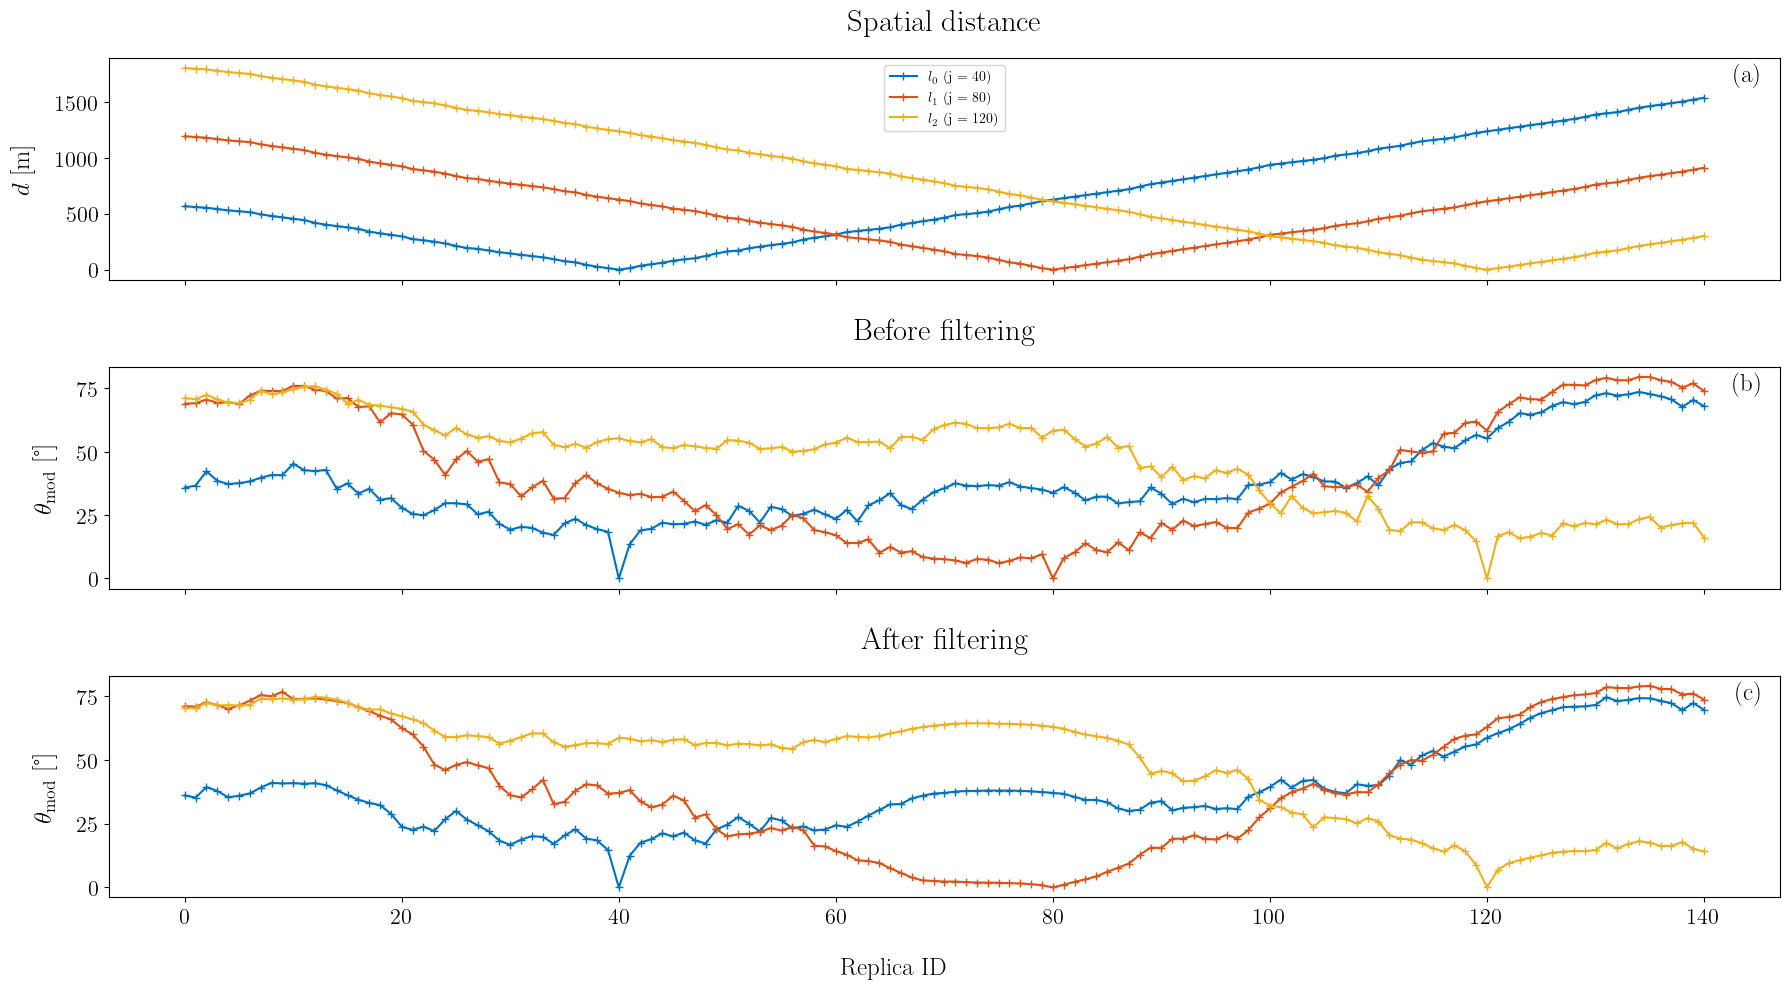

In [151]:
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(18, 10))
ax1, ax2, ax3 = axs

for k, i_l in enumerate(i_ls):
    ax1.plot(
        spatial_dist_mat[i_l, :],
        marker="+",
        color=color(k),
        label=rf"$l_{k}$ (j = {i_l})",
    )
    ax2.plot(
        theta_mat_mod[i_l, :],
        marker="+",
        linestyle="-",
        color=color(k),
        label=rf"$l_{k}$ (j = {i_l})",
    )
    ax3.plot(
        theta_mat_mod_smooth[i_l, :],
        marker="+",
        linestyle="-",
        color=color(k),
        label=rf"$l_{k}$ (j = {i_l})",
    )

ax1.set_ylabel(r"$d$ [m]")
ax2.set_ylabel(r"$\theta_\text{mod}$ [°]")
ax3.set_ylabel(r"$\theta_\text{mod}$ [°]")

ax1.set_title("Spatial distance")
ax2.set_title("Before filtering")
ax3.set_title("After filtering")

ax1.legend()
# ax2.legend()
fig.supxlabel("Replica ID")


set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.99, y_pos=0.98, ha="right", va="top"
)

fpath = os.path.join(
    fig_folder,
    f"bootstrap_theta_module_selected_lines_var.png",
)

plt.savefig(fpath)

Pas de variations significatives. 